<a href="https://colab.research.google.com/github/kausarfatima2626/colorectal_cancer_prediction_test.ipynb/blob/main/colorectal_cancer_prediction_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [19]:

# Load the dataset
df = pd.read_csv('/content/sample_data/colorectal_cancer_prediction.csv.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()



Dataset Shape: (89945, 30)

First 5 Rows:


,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

--- Missing Values Check ---
Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64


/tmp/ipykernel_4626/96391218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survival_Status', palette='Set2')


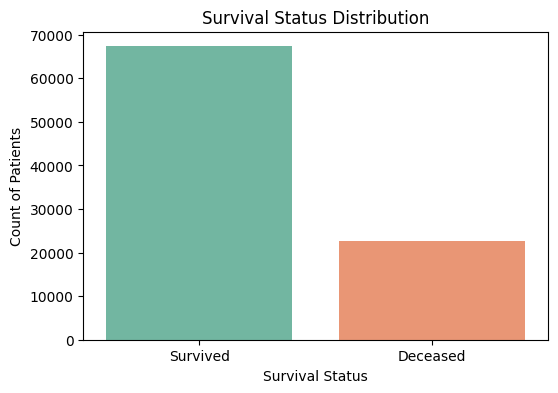


Survival Count:
Survival_Status
Survived    67341
Deceased    22604
Name: count, dtype: int64

Survival Percentage:
Survival_Status
Survived    74.869087
Deceased    25.130913
Name: proportion, dtype: float64


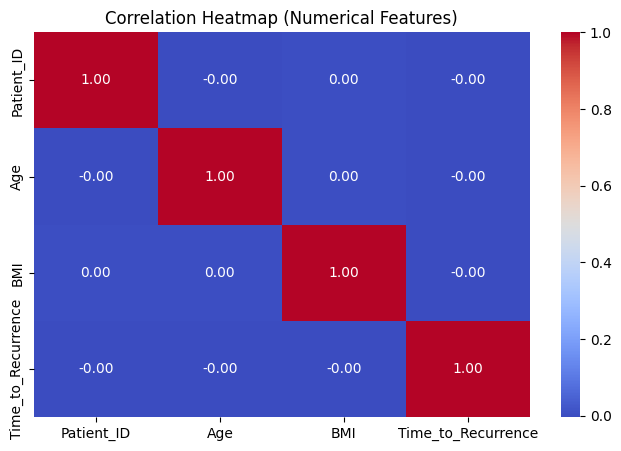

In [20]:

# 1. Check for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# 2. Visualize survival status distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survival_Status', palette='Set2')
plt.title('Survival Status Distribution')
plt.xlabel('Survival Status')
plt.ylabel('Count of Patients')
plt.show()

# Print exact numbers and percentages
print("\nSurvival Count:")
print(df['Survival_Status'].value_counts())
print("\nSurvival Percentage:")
print(df['Survival_Status'].value_counts(normalize=True) * 100)

# 3. Correlation heatmap (numerical features only)
plt.figure(figsize=(8, 5))
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Existing df copy & drop unnecessary columns
df_clean = df.copy()
df_clean = df_clean.drop(columns=['Patient_ID'], errors='ignore')

# 2. Handle missing values & Clean Target Variable
df_clean['Survival_Status'] = df_clean['Survival_Status'].astype(str).str.strip()
df_clean['Survival_Status'] = df_clean['Survival_Status'].map({'Survived': 1, 'Deceased': 0})
df_clean = df_clean.dropna(subset=['Survival_Status'])

# 3. Encode Categorical Variables (One-Hot Encoding)
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 4. Define Features (X) and Target (y)
X = df_encoded.drop(columns=['Survival_Status'])
y = df_encoded['Survival_Status']

# 5. Normalize/Scale Numerical Features
num_cols = ['Age', 'BMI', 'Time_to_Recurrence']
scaler = StandardScaler()

# Scaling numerical features
X[num_cols] = scaler.fit_transform(X[num_cols])

# 6. Split into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("--------------------------------------------------")
print("✅ DATA PREPROCESSING COMPLETE!")
print("--------------------------------------------------")
print("1. Missing values handled successfully.")
print("2. Categorical features encoded into numbers.")
print("3. Numerical features (Age, BMI, Time_to_Recurrence) Normalized/Scaled.")
print(f"4. Total Training Samples: {X_train.shape[0]} rows")
print(f"5. Total Testing Samples: {X_test.shape[0]} rows")
print(f"6. Total Features: {X_train.shape[1]} columns")
print("--------------------------------------------------")

--------------------------------------------------
✅ DATA PREPROCESSING COMPLETE!
--------------------------------------------------
1. Missing values handled successfully.
2. Categorical features encoded into numbers.
3. Numerical features (Age, BMI, Time_to_Recurrence) Normalized/Scaled.
4. Total Training Samples: 71956 rows
5. Total Testing Samples: 17989 rows
6. Total Features: 45 columns
--------------------------------------------------


## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1.
df_clean = df.copy()

# 2. Drop unnecessary columns
df_clean = df_clean.drop(columns=['Patient_ID'], errors='ignore')

# 3. Target variable clean
df_clean['Survival_Status'] = df_clean['Survival_Status'].astype(str).str.strip()

# 4. Target Mapping: Survived -> 1, Deceased -> 0
mapping = {'Survived': 1, 'Deceased': 0}
df_clean['Survival_Status'] = df_clean['Survival_Status'].map(mapping)

# 5. Drop NaN in target variable if any
df_clean = df_clean.dropna(subset=['Survival_Status'])

# 6. One-Hot Encoding for categorical text columns
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 7. Define features (X) and target (y)
X = df_encoded.drop(columns=['Survival_Status'])
y = df_encoded['Survival_Status']

print("✅ Data Preprocessing Successful! Cleaned dataset rows:", len(df_clean))

# 8. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ Train-Test Split Complete!")

# 9. Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 10. Predictions & Evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n--------------------------------------------------")
print(f"🎯 Model Accuracy Score: {acc * 100:.2f}%")
print("--------------------------------------------------")
print("\n📊 Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Deceased (0)', 'Survived (1)']))

✅ Data Preprocessing Successful! Cleaned dataset rows: 89945
✅ Train-Test Split Complete!

--------------------------------------------------
🎯 Model Accuracy Score: 74.87%
--------------------------------------------------

📊 Detailed Classification Report:

              precision    recall  f1-score   support

Deceased (0)       0.00      0.00      0.00      4521
Survived (1)       0.75      1.00      0.86     13468

    accuracy                           0.75     17989
   macro avg       0.37      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
